# Notebook 05 - MobileNetV2 Transfer Learning: Phase 2 (Fine-Tuning)

**Project:** Image-Based Fruit Ripeness Classification  
**Student:** Corneliu Rosca | STU141830  
**Week:** 6

---

## Objective

Fine-tune the Phase 1 model so the high-level convolutional features adapt to the fruit domain, without destroying the pre-trained ImageNet representations:

1. Reload the Phase 1 checkpoint `mobilenet_phase1_best.h5`.
2. Unfreeze the MobileNetV2 base from layer index 100 onward (the final inverted-residual blocks); keep all layers below frozen.
3. Keep every BatchNormalization layer frozen (inference mode), preserving the ImageNet population statistics.
4. Recompile with a low learning rate (1e-5) and continue training for up to 20 epochs.
5. Save the best checkpoint, the history, and a combined Phase 1 -> Phase 2 training-curve figure.

## Strategy and rationale

Phase 1 trains only the head; the convolutional features remain exactly as learned on ImageNet. Phase 2 allows the upper, more task-specific layers to adjust. The two safeguards against overfitting on 315 training images are (a) a learning rate 100x smaller than Phase 1, and (b) frozen BatchNormalization, which prevents the small training batches from corrupting the pre-trained normalisation statistics. These follow the official TensorFlow/Keras fine-tuning guidance.

## Note on reproducibility

`SEED = 42`. Logic is delegated to `src/` (`build_mobilenetv2_finetune`, `build_mobilenet_datasets`). The checkpoint `saved_models/mobilenet_phase2_best.h5` already exists; re-running reproduces an equivalent model and overwrites it.

## 1. Setup and imports

In [8]:
%matplotlib inline
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import callbacks

from src.utils import set_seeds, ensure_dirs, save_history_csv, SAVED_MODELS
from src.data_pipeline import build_mobilenet_datasets
from src.models import build_mobilenetv2_finetune

set_seeds(42)
PROJECT_ROOT = Path.cwd().parent
print('TensorFlow :', tf.__version__)


[utils] Seeds fixed to 42
TensorFlow : 2.11.0


## 2. Load data

The same MobileNetV2 pipeline as Phase 1 (pre-processing to [-1, 1], identical augmentation), so the only change between phases is which layers are trainable and the learning rate.

In [9]:
train_ds, val_ds, test_ds, class_names = build_mobilenet_datasets(
    splits_dir=str(PROJECT_ROOT / 'dataset_splits'),
    batch_size=32, seed=42, augment=True,
)
print('Classes:', class_names)


Found 315 files belonging to 9 classes.
Found 63 files belonging to 9 classes.
Found 72 files belonging to 9 classes.
Classes: ['apple_overripe', 'apple_ripe', 'apple_unripe', 'banana_overripe', 'banana_ripe', 'banana_unripe', 'pear_overripe', 'pear_ripe', 'pear_unripe']


## 3. Load Phase 1 and unfreeze for fine-tuning

`build_mobilenetv2_finetune` reloads the Phase 1 model, unfreezes the base from layer 100, keeps every BatchNormalization layer frozen, and recompiles at learning rate 1e-5. The printout reports how many layers are frozen/unfrozen and the resulting trainable parameter count.

In [10]:
phase1_ckpt = PROJECT_ROOT / 'saved_models' / SAVED_MODELS['mobilenet_phase1']
model = build_mobilenetv2_finetune(str(phase1_ckpt), fine_tune_at=100, learning_rate=1e-5)


[models] Loaded Phase 1 model from d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\saved_models\mobilenet_phase1_best.h5
[models] Phase 2 - cutoff=100 | base layers: 118 frozen, 36 unfrozen | BatchNorm frozen: 52
[utils] Model summary saved to saved_models/model_summary_mobilenet_phase2.txt
[models] Phase 2 - Trainable params: 1,851,145 / 2,269,513


## 4. Callbacks

Same structure as Phase 1, with early-stopping patience raised to 6 (fine-tuning improves more gradually) and minimum learning rate lowered to 1e-7.

In [11]:
ckpt = PROJECT_ROOT / 'saved_models' / SAVED_MODELS['mobilenet_phase2']
cb = [
    callbacks.ModelCheckpoint(str(ckpt), monitor='val_loss', save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
]


## 5. Fine-tune

In [12]:
history = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=cb, verbose=1)
save_history_csv(history, output_path=str(PROJECT_ROOT / 'results' / 'history_mobilenet_phase2.csv'))


Epoch 1/20
10/10 [==============================] - ETA: 0s - loss: 0.1236 - accuracy: 0.9587
Epoch 1: val_loss improved from inf to 0.42039, saving model to d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\saved_models\mobilenet_phase2_best.h5
10/10 [==============================] - 9s 515ms/step - loss: 0.1236 - accuracy: 0.9587 - val_loss: 0.4204 - val_accuracy: 0.8571 - lr: 1.0000e-05
Epoch 2/20
10/10 [==============================] - ETA: 0s - loss: 0.0866 - accuracy: 0.9778
Epoch 2: val_loss improved from 0.42039 to 0.39991, saving model to d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\saved_models\mobilenet_phase2_best.h5
10/10 [==============================] - 7s 456ms/step - loss: 0.0866 - accuracy: 0.9778 - val_loss: 0.3999 - val_accuracy: 0.8571 - lr: 1.0000e-05
Epoch 3/20
10/10 [==============================] - ETA: 0s - loss: 0.0800 - accuracy: 0.9746
Epoch 3: val_loss improved from 0.39991 to 0.38800, saving model to d:\Arden Uni\I

## 6. Combined training curves (Phase 1 -> Phase 2)

The Phase 1 history is read back and concatenated with Phase 2, with a dashed line marking the transition. A drop in validation loss after the transition indicates that fine-tuning helped. This figure is the report's Figure 14.

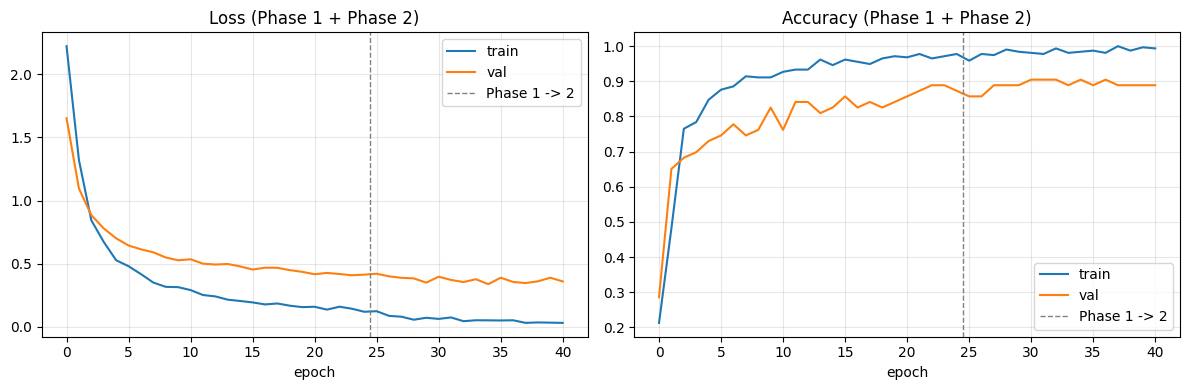

Saved: d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\results\mobilenet_phase2_training_curves.png


In [13]:
p1_csv = PROJECT_ROOT / 'results' / 'history_mobilenet_phase1.csv'
p1 = pd.read_csv(p1_csv) if p1_csv.exists() else None
h = history.history
if p1 is not None:
    split = len(p1)
    loss = list(p1['loss']) + h['loss']; vloss = list(p1['val_loss']) + h['val_loss']
    acc = list(p1['accuracy']) + h['accuracy']; vacc = list(p1['val_accuracy']) + h['val_accuracy']
    suffix = ' (Phase 1 + Phase 2)'
else:
    split = None; loss, vloss, acc, vacc = h['loss'], h['val_loss'], h['accuracy'], h['val_accuracy']
    suffix = ' (Phase 2 only)'
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(loss, label='train'); ax[0].plot(vloss, label='val'); ax[0].set_title('Loss' + suffix)
ax[1].plot(acc, label='train'); ax[1].plot(vacc, label='val'); ax[1].set_title('Accuracy' + suffix)
if split is not None:
    for a in ax: a.axvline(split - 0.5, color='gray', ls='--', lw=1, label='Phase 1 -> 2')
for a in ax: a.set_xlabel('epoch'); a.legend(); a.grid(True, alpha=0.3)
plt.tight_layout()
out = PROJECT_ROOT / 'results' / 'mobilenet_phase2_training_curves.png'
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print('Saved:', out)


## 7. Summary and comparison with Phase 1

In [14]:
vl, va = h['val_loss'], h['val_accuracy']; b = int(np.argmin(vl))
print('=' * 56)
print('  PHASE 2 FINE-TUNING SUMMARY')
print('=' * 56)
print(f'  Epochs run        : {len(vl)}')
print(f'  Best epoch        : {b + 1} (min val_loss)')
print(f'  Best val_loss     : {vl[b]:.4f}')
print(f'  Best val_accuracy : {va[b]:.4f} ({va[b]*100:.2f}%)')
print(f'  Train_acc at best : {h["accuracy"][b]:.4f}')
if p1 is not None:
    pb = int(np.argmin(p1['val_loss']))
    print(f'  Phase 1 val_acc   : {p1["val_accuracy"][pb]*100:.2f}%')
    print(f'  Delta (P2 - P1)   : {(va[b]-p1["val_accuracy"][pb])*100:+.2f} pp')
print(f'  Checkpoint        : {ckpt}')
print('=' * 56)
print('Next: Notebook 06 evaluates both models on the held-out test set.')


  PHASE 2 FINE-TUNING SUMMARY
  Epochs run        : 16
  Best epoch        : 10 (min val_loss)
  Best val_loss     : 0.3378
  Best val_accuracy : 0.9048 (90.48%)
  Train_acc at best : 0.9841
  Phase 1 val_acc   : 88.89%
  Delta (P2 - P1)   : +1.59 pp
  Checkpoint        : d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\saved_models\mobilenet_phase2_best.h5
Next: Notebook 06 evaluates both models on the held-out test set.
